# <center>Rozwiązywanie układów równań</center>

Instrukcja:
Na zajęciach należy wykonać poniższe zadania, a następnie sporządzić sprawozdanie zawierające odpowiedzi (w postaci kodu) z komentarzami w środowisku Jupyter Notebook i umieścić je na platformie e-learningowej.   

In [1]:
import main
import numpy as np
import scipy 
import matplotlib
import matplotlib.pyplot as plt

**Cel zajęć:** Celem zajęć jest zapoznanie się z numerycznymi metodami rozwiązywania układów równań liniowych. To podstawowe zadanie algebry liniowej które macierzowo możemy zapisać jako:  
  
$
\mathbf{Ax}=\mathbf{b}
$ 
  
gdzie $\mathbf{A}$ - macierz współczynników, $\mathbf{x}$ - wektor zmiennych a $\mathbf{b}$ - wektor wyników prawej strony równania.  

Do oceny jakości rozwiązania będziemy wykorzystywać residuum (ang. *residual*)
$
\mathbf{r}=\mathbf{b}-\mathbf{Ax}
$ 
  

***Zadanie 1***   
 
1. Zaimplementuj funkcje *random\_matrix\_Ab* według opisu w pliku main.py generującą macierz kwadratową $\mathbf{A}$ i wektor $\mathbf{b}$ o zadanych wymiarach odpowiednio $m\times m$, $m\times 1$ i o wartościach losowych. W tym celu skorzystaj z funkcji *[randint](https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.random.randint.html)*. W razie podania nieprawidłowej wartości m funkcja ma zwrócić wartość None.

2. Wygeneruj takie macierze dla $m=10,\ 20,\ 50,\ 100,\ 1000$. 


In [2]:
m=[10,20,50,100,1000]
matrixes_and_b=[]
for i in m:
    matrixes_and_b.append(main.random_matrix_Ab(i))

***Zadanie 2***   
 
1. Dla macierzy i wektorów wygenerowanych w poprzednim zadaniu znajdź rozwiązanie układu równań $\mathbf{Ax}=\mathbf{b}$ używając funkcji *[solve](https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.linalg.solve.html?highlight=solve#numpy.linalg.solve)*. 

2. Zaimplementuj normę residual_norm zgodnie z opisem z main.py (używając *[norm](https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.linalg.norm.html?highlight=norm#numpy.linalg.norm)*) sprawdź dokładność otrzymanego rozwiązania (oblicz normę residuum).

3. Określ uwarunkowanie macierzy $\mathbf{A}$ przy pomocy funkcji *[cond](https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.linalg.cond.html?highlight=cond#numpy.linalg.cond)*. 

4. Odpowiedź na pytanie czy zakres wartości oraz wymiary macierzy mają wpływ na jakość otrzymanych wyników? 
  

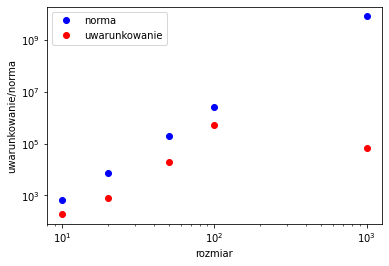

In [3]:
norm=[]
cond=[]
rang=[]
for i in range(5):
  s=np.linalg.solve(matrixes_and_b[i][0],matrixes_and_b[i][1])
  norm.append(main.residual_norm(matrixes_and_b[i][0],matrixes_and_b[i][1],s))
  cond.append(np.linalg.cond(matrixes_and_b[i][0]))
  rang.append(abs(np.amax(matrixes_and_b[i][0])-np.amin(matrixes_and_b[i][0])))
plt.plot(m,norm,'bo',label='norma')
plt.xlabel("rozmiar")
plt.ylabel("uwarunkowanie/norma")
plt.semilogx()
plt.semilogy()
plt.plot(m,cond,'ro',label='uwarunkowanie')
plt.semilogx()
plt.semilogy()
plt.legend()



[]

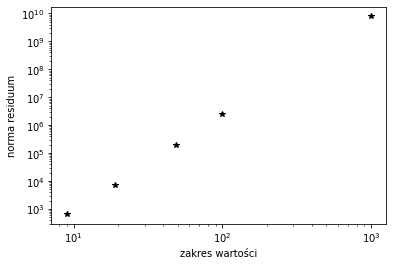

In [4]:
plt.plot(rang,norm,'k*',label='zakres wartości')
plt.xlabel("zakres wartości")
plt.ylabel("norma residuum")
plt.semilogx()
plt.semilogy()

  Po wielu odtworzeniach programu i losowaniu tworzeniu nowych macierzy dochodzę do wniosku że rozmiar macierzy jest proporcjonalny do niedokładności otrzymywanych wyników. Powodowane to może być nakładaniem się błędów zaokrągleń w czasie rozwiązywania układów równań.
   Tak samo zakres wartości, co byłoby zgodne ze wzorem k=||A|| ||A^(-1)|| gdyż wraz ze wzrostem wartości rośnie norma a z nią uwarunkowie, co ułatwia przenoszenie błędów.


***Zadanie 3***  
Rozkład dowolnej macierzy metodą  *[dekompozycji na wartości singularne](https://pl.wikipedia.org/wiki/Rozk%C5%82ad_wed%C5%82ug_warto%C5%9Bci_osobliwych)* można w Pythonie przeprowadzić przy pomocy funkcji *[svd](https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.linalg.svd.html)*. Rozkład dla przykładowej macierzy obrazuje kod: 

In [5]:
import numpy as np
import numpy.linalg as nplin

A = np.array([[1,2,3],[1,2,3],[1,2,3]])

# Użycie rozkładu SVD na macierzy A
U,S,V = nplin.svd(A)

print(S)
# Odtworzenie macierzy A przy pomocy metody SVD
A2 = np.dot(U * S, V)
 
print("Macierz A:\n {0}".format(A))
print("Macierz odtworzona z SVD:\n {0}".format(A2))

[6.48074070e+00 1.29219214e-16 7.69636854e-34]
Macierz A:
 [[1 2 3]
 [1 2 3]
 [1 2 3]]
Macierz odtworzona z SVD:
 [[1. 2. 3.]
 [1. 2. 3.]
 [1. 2. 3.]]


Wykonaj następujące kroki:

1. Zdefiniuj funkcję inicjalizujące wektory *wartości singularnych* w następujący sposób:
    - wektor nierosnących wartości singularnych w postaci wektora przestrzeni logarytmicznej,
    - wektor nierosnących wartości singularnych, gdzie jedna wartość jest znacznie większa od pozostałych,
    - wektor nierosnących wartości, gdzie jedna wartość jest znacznie mniejsza od pozostałych. 
    
    W celu inicjalizacji takich wektorów zaimplementuje funkcje:  
    - *log\_sing\_value* zgodnie z opisem w main.py i użyciu funkcji *[logspace](https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.logspace.html?highlight=logspace#numpy.logspace)*
    - *order\_sing\_value* zgodnie z opisem w main.py

2. Zdefiniuj funkcję *create_matrix_from_A* z pliku main, która dla zadanej macierzy A z *zadania 1* i wektorów warości singularnych z punktu 1. tego zadania będzie zwracać odtworzoną macierz z podmienionym wektorem warości singularnych przy pomocy metody SVD, jak pokazanow w przykładzie wyżej. 

3. Dla otrzymanych macierzy oblicz wartości współczynnika uwarunkowania. 

4. Odpowiedz na pytanie: czy konieczne jest wyliczanie macierzy aby to zrobić?

5. Dla każdego $m$ sporządź wykres normy residuów rozwiązań i funkcji uwarunkowania macierzy. 




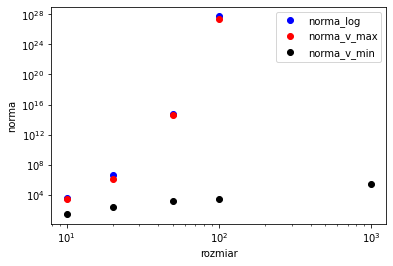

In [8]:
norm_v_log=[]
norm_v_min=[]
norm_v_max=[]
cond_v_min=[]
cond_v_log=[]
cond_v_max=[]
for i in range(5):
    v_log=main.log_sing_value(m[i],0,m[i]/4)
    v_min=main.order_sing_value(m[i],m[i]/4,'low')
    v_max=main.order_sing_value(m[i],m[i]/4,'gre')

    A=main.create_matrix_from_A(matrixes_and_b[i][0],v_log)
    s=np.linalg.solve(A,matrixes_and_b[i][1])
    norm_v_log.append(main.residual_norm(A,matrixes_and_b[i][1],s))
    cond_v_log.append(np.linalg.cond(A))

    A=main.create_matrix_from_A(matrixes_and_b[i][0],v_min)
    s=np.linalg.solve(A,matrixes_and_b[i][1])
    norm_v_min.append(main.residual_norm(A,matrixes_and_b[i][1],s))
    cond_v_min.append(np.linalg.cond(A))

    A=main.create_matrix_from_A(matrixes_and_b[i][0],v_max)
    s=np.linalg.solve(A,matrixes_and_b[i][1])
    norm_v_max.append(main.residual_norm(A,matrixes_and_b[i][1],s))
    cond_v_max.append(np.linalg.cond(A))
    
plt.plot(m,norm_v_log,'bo',label='norma_log')
plt.plot(m,norm_v_max,'ro',label='norma_v_max')
plt.plot(m,norm_v_min,'ko',label='norma_v_min')
plt.xlabel("rozmiar")
plt.ylabel("norma")
plt.semilogx()
plt.semilogy()
plt.semilogx()
plt.semilogy()
plt.legend()

[]

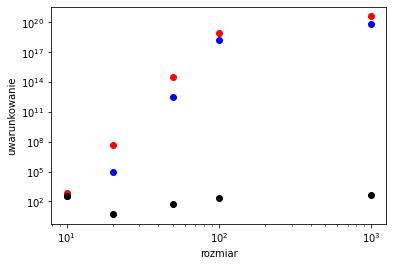

In [7]:
plt.plot(m,cond_v_log,'bo',label='cond_log')
plt.plot(m,cond_v_max,'ro',label='cond_max')
plt.plot(m,cond_v_min,'ko',label='cond_min')
plt.xlabel("rozmiar")
plt.ylabel("uwarunkowanie")
plt.semilogx()
plt.semilogy()
plt.semilogx()
plt.semilogy()
# plt.legend()

Największe błędy były widoczne dla wartości singularnych rozłożonych logarytmicznie, przy czym niewiele one ustępowały tym wśród których była zaledwie jedna duża wartość, co świadczyć może o tym że największe znaczenie ma największy element, bo po niewielkich w prównaniu z innymi niedokładnościach dla wektorów z jedną szczególnie mniejszą od innych wartościach można wnioskować że stosunek wartości singularnych do siebie nie ma znaczenia lecz największa z nich.
 Tak samo rzecz się ma z uwarunkowaniem macierzy.


4. Wystarczy znać wartości singularne

Wnioski
Podczas zapisywania danych  w macierzy warto się zastanowić nad możliwościa zzmniejszenia jej rozmiaru i takiego zapisania ich by największa wartość była jak najmniejsza w celu zmniejszenia zakresu wartości macierzy. Może nawet te największe przenaczyć do innej macierzy i wykonać jak najwięcej obliczeń na nich bez ich łączenia.

Materiały uzupełniające:
- [Scipy Lecture Notes](http://www.scipy-lectures.org/index.html)
- [NumPy for Matlab users](https://docs.scipy.org/doc/numpy/user/numpy-for-matlab-users.html#numpy-for-matlab-users)
- [Python Tutorial - W3Schools](https://www.w3schools.com/python/default.asp)
- [NumPy](https://www.numpy.org)
- [Matplotlib](https://matplotlib.org/)
- [Anaconda](https://www.anaconda.com/)
- [Learn Python for Data Science](https://www.datacamp.com/learn-python-with-anaconda?utm_source=Anaconda_download&utm_campaign=datacamp_training&utm_medium=banner)
- [Learn Python](https://www.learnpython.org/)
- [Wujek Google](https://google.pl) i [Ciocia Wikipedia](https://pl.wikipedia.org/wiki/Wikipedia:Strona_g%C5%82%C3%B3wna)